<a href="https://colab.research.google.com/github/kdivyasrija/aiml/blob/main/aimlfrauddetection2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Train test split
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv("financial_transaction_dataset.csv")
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [ ]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#1.model building
# Identify categorical columns
categorical_cols = ['transaction_type', 'merchant_category', 'country']

# Apply one-hot encoding to X_train and X_test
X_train_processed = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - reindex X_test_processed columns to match X_train_processed columns,
# filling missing with 0. This ensures both datasets have the same features after encoding.
missing_cols_in_test = set(X_train_processed.columns) - set(X_test_processed.columns)
for c in missing_cols_in_test:
    X_test_processed[c] = 0
X_test_processed = X_test_processed[X_train_processed.columns]

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_processed, y_train)

KNeighborsClassifier()

In [ ]:
#1.model building
# Identify categorical columns
categorical_cols = ['transaction_type', 'merchant_category', 'country']

# Apply one-hot encoding to X_train and X_test
X_train_processed = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - reindex X_test_processed columns to match X_train_processed columns,
# filling missing with 0. This ensures both datasets have the same features after encoding.
missing_cols_in_test = set(X_train_processed.columns) - set(X_test_processed.columns)
for c in missing_cols_in_test:
    X_test_processed[c] = 0
X_test_processed = X_test_processed[X_train_processed.columns]

# SVM Model
svm = SVC(kernel='rbf')
svm.fit(X_train_processed, y_train)

SVC()

In [ ]:
#1.model building
# Identify categorical columns
categorical_cols = ['transaction_type', 'merchant_category', 'country']

# Apply one-hot encoding to X_train and X_test
X_train_processed = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - reindex X_test_processed columns to match X_train_processed columns,
# filling missing with 0. This ensures both datasets have the same features after encoding.
missing_cols_in_test = set(X_train_processed.columns) - set(X_test_processed.columns)
for c in missing_cols_in_test:
    X_test_processed[c] = 0
X_test_processed = X_test_processed[X_train_processed.columns]

# Naive Bayes Model
nb = GaussianNB()
nb.fit(X_train_processed, y_train)

GaussianNB()

In [ ]:
#1.model building
# Identify categorical columns
categorical_cols = ['transaction_type', 'merchant_category', 'country']

# Apply one-hot encoding to X_train and X_test
X_train_processed = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - reindex X_test_processed columns to match X_train_processed columns,
# filling missing with 0. This ensures both datasets have the same features after encoding.
missing_cols_in_test = set(X_train_processed.columns) - set(X_test_processed.columns)
for c in missing_cols_in_test:
    X_test_processed[c] = 0
X_test_processed = X_test_processed[X_train_processed.columns]

# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#2.Predictions

y_pred_knn = knn.predict(X_test_processed)
y_pred_svm = svm.predict(X_test_processed)
y_pred_nb = nb.predict(X_test_processed)
y_pred_rf = rf.predict(X_test_processed)

In [ ]:
def evaluate_model(y_true, y_pred, model_name):

    print("Model:", model_name)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))
    print("\n----------------------------------\n")

In [ ]:
#2.performance evaluation
evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_svm, "SVM")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_rf, "Random Forest")

Model: KNN
Accuracy: 0.9995
Precision: 1.0
Recall: 0.9911504424778761
F1 Score: 0.9955555555555555

Confusion Matrix
[[1887    0]
 [   1  112]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1887
           1       1.00      0.99      1.00       113

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Model: SVM
Accuracy: 0.9945
Precision: 1.0
Recall: 0.9026548672566371
F1 Score: 0.9488372093023256

Confusion Matrix
[[1887    0]
 [  11  102]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1887
           1       1.00      0.90      0.95       113

    accuracy                           0.99      2000
   macro avg       1.00      0.95      0.97      2000
weighted avg       0.99      0.99      0.99      2000

Model: Naive

In [ ]:
#3.KNN Hyperparameter Tuning
knn_params = {
    'n_neighbors':[3,5,7,9]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
grid_knn.fit(X_train_processed, y_train)

best_knn = grid_knn.best_estimator_

print("Best KNN Parameters:", grid_knn.best_params_)

Best KNN Parameters: {'n_neighbors': 3}


In [ ]:
#3.SVM Hyperparameter Tuning
svm_params = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf']
}

grid_svm = GridSearchCV(SVC(), svm_params, cv=5)
grid_svm.fit(X_train_processed, y_train)

best_svm = grid_svm.best_estimator_

print("Best SVM Parameters:", grid_svm.best_params_)

Best SVM Parameters: {'C': 0.1, 'kernel': 'linear'}


In [ ]:
#3.Random Forest Hyperparameter Tuning
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,20]
}

grid_rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=5)
grid_rf.fit(X_train_processed, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF Parameters:", grid_rf.best_params_)

Best RF Parameters: {'max_depth': 5, 'n_estimators': 100}


In [ ]:
#4.PERFORMANCE EVALUATION AFTER HYPERPARAMETER TUNING
# Predictions with tuned models

y_pred_knn_tuned = best_knn.predict(X_test_processed)
y_pred_svm_tuned = best_svm.predict(X_test_processed)
y_pred_rf_tuned = best_rf.predict(X_test_processed)

# Evaluate tuned models

evaluate_model(y_test, y_pred_knn_tuned, "Tuned KNN")
evaluate_model(y_test, y_pred_svm_tuned, "Tuned SVM")
evaluate_model(y_test, y_pred_rf_tuned, "Tuned Random Forest")

Model: Tuned KNN
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix
[[1887    0]
 [   0  113]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1887
           1       1.00      1.00      1.00       113

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Model: Tuned SVM
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix
[[1887    0]
 [   0  113]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1887
           1       1.00      1.00      1.00       113

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Model: Tuned Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.

In [ ]:
#COMPARISON AND ANALYSIS
results = pd.DataFrame({

'Model':[
'KNN',
'SVM',
'Naive Bayes',
'Random Forest'
],

'Accuracy':[
accuracy_score(y_test,y_pred_knn),
accuracy_score(y_test,y_pred_svm),
accuracy_score(y_test,y_pred_nb),
accuracy_score(y_test,y_pred_rf)
],

'Precision':[
precision_score(y_test,y_pred_knn),
precision_score(y_test,y_pred_svm),
precision_score(y_test,y_pred_nb),
precision_score(y_test,y_pred_rf)
],

'Recall':[
recall_score(y_test,y_pred_knn),
recall_score(y_test,y_pred_svm),
recall_score(y_test,y_pred_nb),
recall_score(y_test,y_pred_rf)
],

'F1 Score':[
f1_score(y_test,y_pred_knn),
f1_score(y_test,y_pred_svm),
f1_score(y_test,y_pred_nb),
f1_score(y_test,y_pred_rf)
]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.9995,1.0,0.991150,0.995556
1,SVM,0.9945,1.0,0.902655,0.948837
2,Naive Bayes,1.0000,1.0,1.000000,1.000000
3,Random Forest,1.0000,1.0,1.000000,1.000000


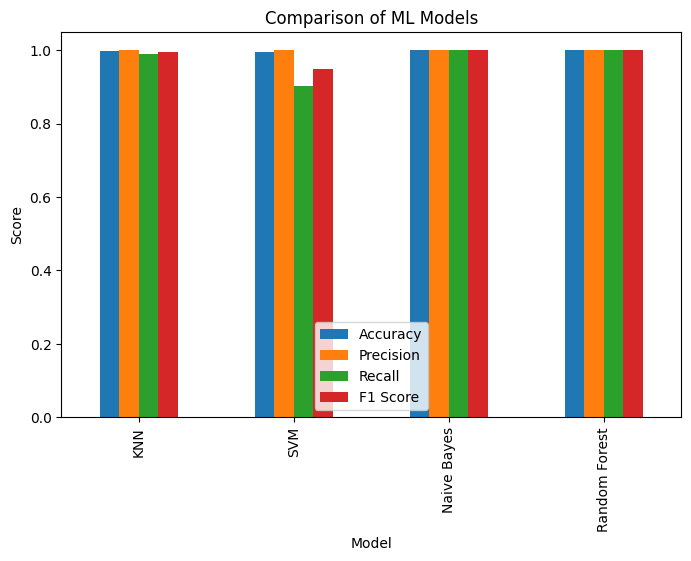

In [ ]:
#Visual Comparison
results.set_index('Model').plot(kind='bar', figsize=(8,5))

plt.title("Comparison of ML Models")
plt.ylabel("Score")
plt.show()